# DMO[1-4] -> Fatigue[4] (weekly)
This will take all 4 visits for each patient and concat them together so that it only predicts the final value

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from src.core.data_transforms import Transform
from src.model import DMORandomForestRegressor

import numpy as np
import torch
import shap

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [4]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [6]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [7]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [8]:
print(dmo_data.shape)

torch.Size([428, 4, 7, 25])


In [9]:
dmo_data = dmo_data.mean(axis=2)

In [10]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [11]:
# shuffle
patients, *other = dmo_data.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

dmo_data = dmo_data[random_permutation]
dmo_labels = dmo_labels[random_permutation]

In [12]:
dmo_data_split = torch.tensor_split(dmo_data, K_FOLDS)
dmo_label_split = torch.tensor_split(dmo_labels, K_FOLDS)

prediction_arr = []
actual_arr = []
shap_values = []
test_inputs = []
baseline_values = []

for split_i in range(K_FOLDS):
    test_label = dmo_label_split[split_i]
    test_data = dmo_data_split[split_i]

    train_label = torch.cat(
        [dmo_label_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    train_data = torch.cat(
        [dmo_data_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    
    test_data = test_data.flatten(start_dim=1, end_dim=2)
    test_label = test_label.flatten(start_dim=1, end_dim=2)[:, -1]
    
    train_data = train_data.flatten(start_dim=1, end_dim=2)
    train_label = train_label.flatten(start_dim=1, end_dim=2)[:, -1]
    
    # normalise data
    scaler = StandardScaler()
    scaler.fit(train_data)
    
    train_data = scaler.transform(train_data)
    test_data = scaler.transform(test_data)
    
    rf_model = DMORandomForestRegressor(n_trees=500)

    rf_model.train(train_data, train_label)
    score = rf_model.score(test_data, test_label)
    print(score)
    
    prediction = torch.tensor(rf_model.predict(test_data))
    prediction = label_normaliser.scaler_inverse_labels(prediction)
    
    actual = label_normaliser.scaler_inverse_labels(test_label)
    
    prediction_arr.append(prediction)
    actual_arr.append(actual)
    
    sklearn_rf_model = rf_model.random_forest
    
    test_input_numpy = test_data
    explainer = shap.TreeExplainer(sklearn_rf_model)
    shap_value = explainer.shap_values(test_input_numpy)
    shap_values.append(shap_value)
    test_inputs.append(test_data)
    baseline_values.append(explainer.expected_value)
    

0.1867578889316559
0.14487550444551567
0.22355012297353138
0.14006974249190296
0.06710019724383509


In [13]:
prediction = torch.cat(prediction_arr)
actual = torch.cat(actual_arr)

In [14]:
prediction

tensor([25.7020, 22.5480, 19.6820, 25.1740, 17.1700, 15.8960, 18.6200, 23.1220,
        20.0440, 11.7640, 20.5680, 17.7660, 23.2700, 23.4840, 24.4840, 21.2480,
        20.2700, 20.6660, 17.2860, 21.4040, 21.5480, 21.2960, 15.4200, 18.7440,
        22.8720, 24.1520, 20.6080, 21.2260, 25.3580, 21.2960, 21.6600, 20.3540,
        24.1440, 16.6920, 12.0260, 19.9620, 14.8040, 25.2020, 23.7920, 23.6040,
        19.6200, 22.8960, 17.3700, 23.1120, 15.9180, 12.3520, 14.7920, 23.6980,
        24.2440, 18.3860, 21.3620, 22.8620, 20.0500, 23.3480, 19.3540, 21.2340,
        18.3460, 23.4080, 18.0660, 23.1000, 15.4440, 24.8740, 26.5420, 16.4200,
        20.8600, 18.4360, 20.8620, 23.6640, 11.4140, 19.1340, 13.4600, 16.5400,
        14.5240, 18.3080, 23.0300, 19.8820, 23.3160, 26.6680, 21.1700, 18.1240,
        22.2800, 20.9460, 22.5820, 16.6580, 17.9160, 22.5220, 15.1680, 22.6300,
        21.2340, 22.2840, 24.7860, 18.7380, 21.4260, 24.5520, 23.7140, 24.9040,
        13.6600, 19.3320, 21.7940, 22.04

{'accuracy': 0.007009345794392523, 'Mean Squared Error': 59.59640884399414, 'Mean Absolute Error': 6.220093250274658, 'R^2': 0.1579227945582784}


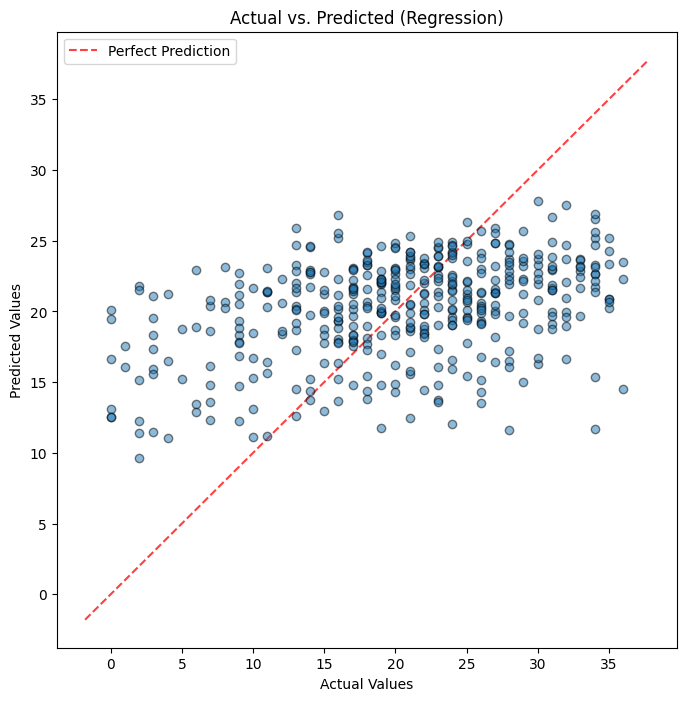

In [15]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

In [16]:
shap_values = np.concat(xvregressor.shap_values, axis=0)
test_inputs = np.concat(xvregressor.test_inputs, axis=0)
baseline_labels = np.mean(xvregressor.baseline_values)

NameError: name 'xvregressor' is not defined

In [ ]:
dmo_data.shape

torch.Size([428, 4, 24])

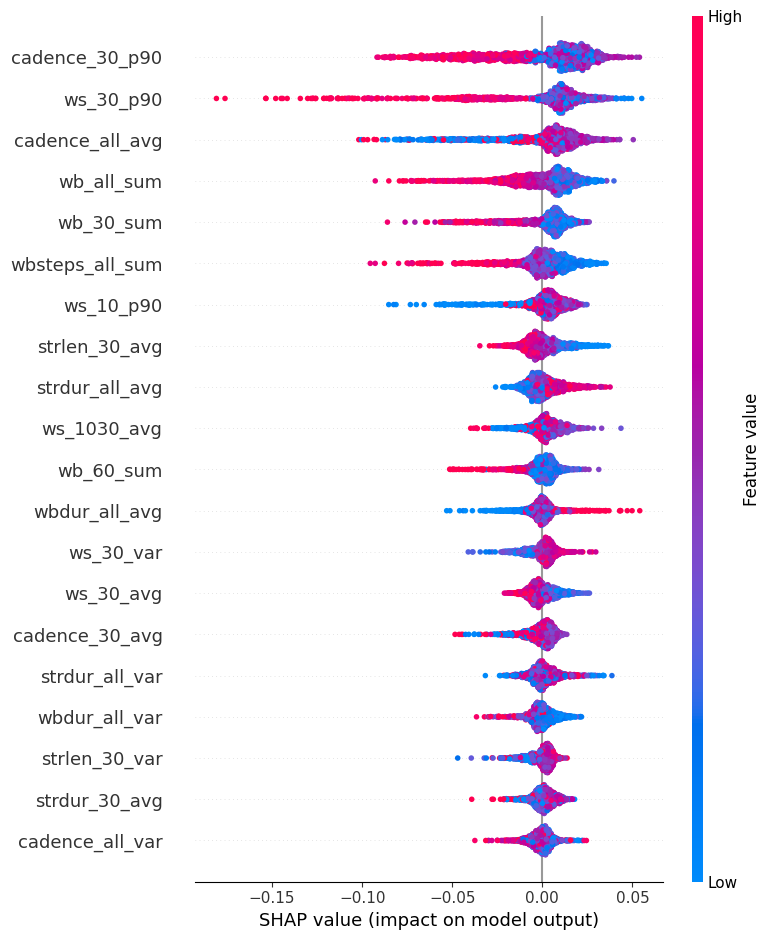

In [ ]:
import shap

#dmo_features = dmo_features + static_features

shap.summary_plot(
    shap_values,
    test_inputs,
    feature_names=dmo_features,
)

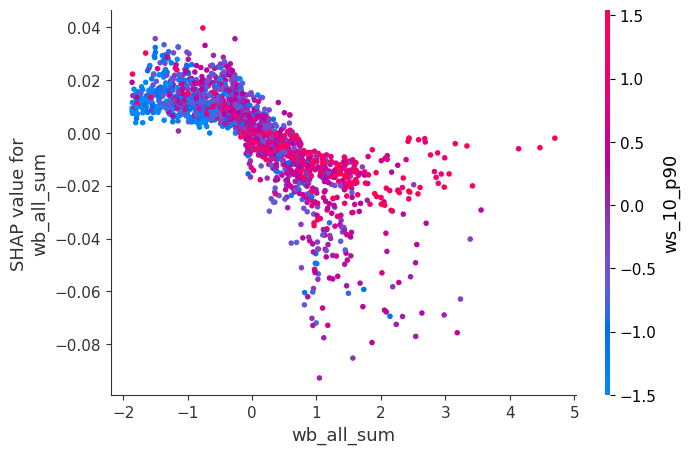

In [ ]:
shap.dependence_plot(
    "wb_all_sum", 
    shap_values, 
    test_inputs, 
    feature_names=dmo_features
)

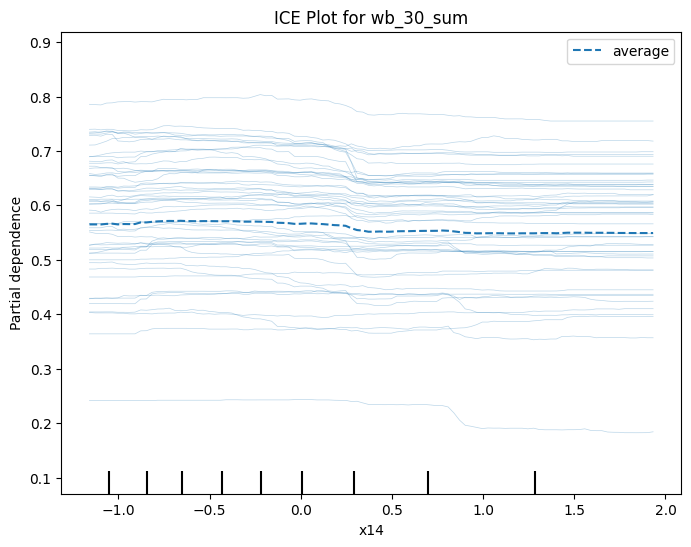

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

feature_index = dmo_features.index("wb_30_sum")

# test_numpy = test_input.numpy()

fig, ax = plt.subplots(figsize=(8, 6))

display = PartialDependenceDisplay.from_estimator(
    xvregressor.rf_model.random_forest, 
    test_inputs, 
    features=[feature_index],
    #feature_names=dmo_features,
    kind='both', 
    subsample=50,
    ax=ax
)

ax.set_title(f"ICE Plot for {dmo_features[feature_index]}")
plt.show()

In [ ]:
# # filter out less fatigued patients to see correlation

# mask = (test_label >= 0.7)
# test_numpy_filtered = test_numpy[mask]
# fig, ax = plt.subplots(figsize=(8, 6))

# display = PartialDependenceDisplay.from_estimator(
#     random_forest_model, 
#     test_numpy_filtered, 
#     features=[feature_index],
#     feature_names=dmo_features,
#     kind='both', 
#     subsample=50,
#     ax=ax
# )

# ax.set_title(f"ICE Plot for {dmo_features[feature_index]}")
# plt.show()

NameError: name 'test_label' is not defined

In [ ]:
index = 1
shap.initjs()

shap.force_plot(
    baseline_labels,             
    shap_values[index],
    test_inputs[index],
    feature_names=dmo_features,
)

NameError: name 'shap' is not defined